# Applied Linear Algebra - Lab 1
Ferdowsi University of Mashhad - Computer Engineering Department

Fall 2021


### Contents:

* [Numpy](#Numpy)
* [Arrays](#Arrays)
* [Array Arithmetic](#Array-Arithmetic)
* [Exercise 1](#Exercise-1)
* [NumPy Standard Data Types](#NumPy-Standard-Data-Types)
* [Using array-generating functions](#Using-array-generating-functions)
* [Exercise 2](#Exercise-2)
* [Exercise 3](#Exercise-3)
* [Array Slicing: Accessing Subarrays](#Array-Slicing:-Accessing-Subarrays)
* [Implementing Gaussian Elimination](#Implementing-Gaussian-Elimination)
* [Exercise 4](#Exercise-4)
* [Exercise 5](#Exercise-5)
* [Exercise 6](#Exercise-6)
* [Exercise 7](#Exercise-7)
* [Exercise 8](#Exercise-8)
* [Exercise 9](#Exercise-9)
* [Polynomial Interpolation](#Polynomial-Interpolation)
* [Exercise 10](#Exercise-10)
* [Color Grading](#Color-Grading)
* [Exercise 11](#Exercise-11)
* [Exercise 12](#Exercise-12)
* [Exercise 13](#Exercise-13)
* [Exercise 14](#Exercise-14)


# Numpy

Datasets can be made of collections of images, sounds, videos, documents, numerical measurements, or, really anything. Despite the diversity, it will help us to think of all data fundamentally as arrays of numbers.

| Data type	    | Arrays of Numbers? |
|---------------|-------------|
|Images | Pixel brightness across different channels|
|Videos | Pixels brightness across different channels for each frame | 
|Sound | Intensity over time |
|Numbers | No need for transformation | 
|Tables | Mapping from strings to numbers |


Therefore, the efficient storage and manipulation of large arrays of numbers is really fundamental to the process of doing data science. Numpy is one of the libraries within the scientific stack that specialize in handling numerical arrays and data tables. 

[Numpy](http://www.numpy.org/) is short for _numerical python_, and provides functions that are especially useful when you have to work with large arrays and matrices of numeric data, like matrix multiplications.  

The array object class is the foundation of Numpy, and Numpy arrays are like lists in Python, except that every thing inside an array must be of the same type, like int or float. As a result, arrays provide much more efficient storage and data operations, especially as the arrays grow larger in size. However, in other ways, NumPy arrays are very similar to Python's built-in list type, but with the exception of Vectorization.

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython import display

# Global floating point precision
precision = 2

## Arrays
A numpy array is a grid of values, all of the same type, and is indexed by a tuple of nonnegative integers. The shape of an array is a tuple of integers giving the size of the array along each dimension. A a one dimensional array (shape `(n,)`) corresponds to a vector.

We can initialize numpy arrays from nested Python lists, and access elements using square brackets:

In [87]:
a = np.array([1, 2, 3])  # Create a 1 dimensional array i.e. a vector

print("a is type: ", type(a))
print("The shape of the vector a is: ", a.shape)
print(a[0], a[1], a[2])  # indexing
a[0] = 5  # Change an element of the array
print(a)     

a is type:  <class 'numpy.ndarray'>
The shape of the vector a is:  (3,)
1 2 3
[5 2 3]


In [88]:
b = np.array([[1,2,3],[4,5,6]])   # Create a 2 dimensional array i.e. a matrix
print(b)
print("The shape of the matrix b is: ", b.shape)
print(b[0, 0], b[0, 1], b[1, 0])

[[1 2 3]
 [4 5 6]]
The shape of the matrix b is:  (2, 3)
1 2 4


## Array Arithmetic
Basic mathematical functions operate elementwise on arrays and matrices (which are just 2D arrays), and are available both as operator overloads and as functions in the numpy module:

In [89]:
# Define two matrices
x = np.array([[1,2],[3,4]])
y = np.array([[5,6],[7,8]])

# Elementwise sum:
print(x + y)
print(np.add(x, y))

[[ 6  8]
 [10 12]]
[[ 6  8]
 [10 12]]


In [90]:
# Elementwise difference:
print(x - y)
print(np.subtract(x, y))

[[-4 -4]
 [-4 -4]]
[[-4 -4]
 [-4 -4]]


In [91]:
# Elementwise product:
#  * is elementwise multiplication, not matrix multiplication!
print(x * y)
print(np.multiply(x, y))

[[ 5 12]
 [21 32]]
[[ 5 12]
 [21 32]]


In [92]:
# Elementwise square root:
print(np.sqrt(x))

[[1.         1.41421356]
 [1.73205081 2.        ]]


In [93]:
# Elementwise division:
print(x / y)
print(np.divide(x, y))

[[0.2        0.33333333]
 [0.42857143 0.5       ]]
[[0.2        0.33333333]
 [0.42857143 0.5       ]]


<!-- BEGIN QUESTION -->

# Exercise 1
Given two vectors $v_1$ and $v_2$, calculate $v_3$ where
$$
v_3 = 12(v_1 - 2v_2)
$$

In [94]:
# define the two vectors
v1 = np.array([2,3,4,7])
v2 = np.array([6,1,0,3])

# calculate v3
v3 = 12*(v1 - 2*v2)
print(v3)

[-120   12   48   12]


<!-- END QUESTION -->

We use the dot function to compute inner products of vectors, to multiply a vector by a matrix, and to multiply matrices. dot is available both as a function in the numpy module and as an instance method of array objects:

In [95]:
x = np.array([[1,2],[3,4]])
y = np.array([[5,6],[7,8]])

v = np.array([9,10])
w = np.array([11, 12])

# Inner product of vectors.
print(v.dot(w))
print(np.dot(v, w))
print(v @ w)

# Matrix multiplication.
print(x.dot(y))
print(np.dot(x, y))
print(x @ y)

x = np.matrix(x)
y = np.matrix(y)
x*y

219
219
219
[[19 22]
 [43 50]]
[[19 22]
 [43 50]]
[[19 22]
 [43 50]]


matrix([[19, 22],
        [43, 50]])

We can cast the array objects to the type `matrix`. This changes the behavior of the standard arithmetic operators +, -, * to use matrix algebra.
Make sure the dimensions of the two matrices are compatible. You can use the `np.transpose()` function or the `T` method of NumPy vectors and matrices.

In [96]:
# Create two row vectors
v = np.matrix(v)
w = np.matrix(w)

# Create two matrices
x = np.matrix(x)
y = np.matrix(y)

# Inner product of vectors.
print(v * w.T)

# Matrix multiplication.
print(x * y)

# Matrix Vector multiplication
print(x * v.T)

[[219]]
[[19 22]
 [43 50]]
[[29]
 [67]]


## NumPy Standard Data Types

NumPy arrays contain values of a single type, so it is important to have detailed knowledge of those types and their limitations.
Because NumPy is built in C, the types will be familiar to users of C, Fortran, and other related languages.

The standard NumPy data types are listed in the following table.
Note that when constructing an array, they can be specified using a string:

```python
np.zeros(10, dtype='int16')
```

Or using the associated NumPy object:

```python
np.zeros(10, dtype=np.int16)
```

| Data type	    | Description |
|---------------|-------------|
| ``bool_``     | Boolean (True or False) stored as a byte |
| ``int_``      | Default integer type (same as C ``long``; normally either ``int64`` or ``int32``)| 
| ``intc``      | Identical to C ``int`` (normally ``int32`` or ``int64``)| 
| ``intp``      | Integer used for indexing (same as C ``ssize_t``; normally either ``int32`` or ``int64``)| 
| ``int8``      | Byte (-128 to 127)| 
| ``int16``     | Integer (-32768 to 32767)|
| ``int32``     | Integer (-2147483648 to 2147483647)|
| ``int64``     | Integer (-9223372036854775808 to 9223372036854775807)| 
| ``uint8``     | Unsigned integer (0 to 255)| 
| ``uint16``    | Unsigned integer (0 to 65535)| 
| ``uint32``    | Unsigned integer (0 to 4294967295)| 
| ``uint64``    | Unsigned integer (0 to 18446744073709551615)| 
| ``float_``    | Shorthand for ``float64``.| 
| ``float16``   | Half precision float: sign bit, 5 bits exponent, 10 bits mantissa| 
| ``float32``   | Single precision float: sign bit, 8 bits exponent, 23 bits mantissa| 
| ``float64``   | Double precision float: sign bit, 11 bits exponent, 52 bits mantissa| 
| ``complex_``  | Shorthand for ``complex128``.| 
| ``complex64`` | Complex number, represented by two 32-bit floats| 
| ``complex128``| Complex number, represented by two 64-bit floats| 

More advanced type specification is possible, such as specifying big or little endian numbers; for more information, refer to the [NumPy documentation](http://numpy.org/).
NumPy also supports compound data types.

## Using array-generating functions

For larger arrays it is inpractical to initialize the data manually, using explicit python lists. Instead we can use one of the many functions in numpy that generate arrays of different forms. Some of the more common are:


In [97]:
# We use these when the elements of the 
# arrays are originally unknown but their size is known.

np.zeros((3,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [98]:
np.ones((2,3), dtype = np.int_)

array([[1, 1, 1],
       [1, 1, 1]])

In [99]:
np.empty( (2,3) )   

array([[ 0. , 10. , 20. ],
       [ 3.5,  3.5,  3.5]])

In [100]:
# Create a 3x5 array filled with 3.14
np.full((3, 5), 3.14)

array([[3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14]])

In [101]:
# Create a 3x3 Identity Matrix
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

<!-- BEGIN QUESTION -->

# Exercise 2
Given vector $v$, calculate the average of its elements using dot product.

In [102]:
# define vector v
v = np.array([ 3, 5, -3, 7, 1 ])

# vector of ones
ones_vector = np.ones((1, v.size), dtype = np.int32)

# calculating the average using dot product
average = (v @ ones_vector.T)/v.size
average

array([2.6])

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 3
Matrices can *transform* the vectors that they are multiplied with.
define vector $ u = [ 3, -4 ]^T $ and matrix $ A = \begin{bmatrix}1&-3\\2&-2 \end{bmatrix}$ then calculate and plot the result of
$ Au$ which we'll call $v$.

Make sure that $u$ is a $2\times1$ column vector.

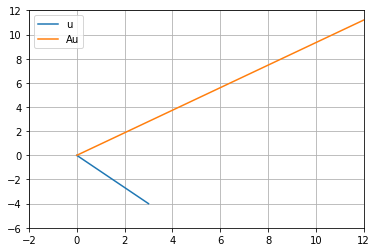

In [103]:
# define the vector. this is a row vector
u = np.array([3, -4])

# define the 2x2 matrix
A = np.array([[1, -3], [2, -2]])

# output vector is Av (convert v to column)
v = A @ u.T


# plotting
plt.plot([0,u[0]],[0,u[1]],label='u')
plt.plot([0,v[0]],[0,v[1]],label='Au')
plt.grid()
plt.axis((-2, 12, -6, 12))
plt.legend()
plt.show()

<!-- END QUESTION -->

### Array Slicing: Accessing Subarrays

Just as we can use square brackets to access individual array elements, we can also use them to access subarrays with the *slice* notation, marked by the colon (``:``) character.
The NumPy slicing syntax follows that of the standard Python list; to access a slice of an array ``x``, use this:
``` python
x[start:stop:step]
```
If any of these are unspecified, they default to the values ``start=0``, ``stop=``*``size of dimension``*, ``step=1``.
We'll take a look at accessing sub-arrays in one dimension and in multiple dimensions.

In [104]:
M = np.random.randint(100, size=(10, 12))
print("Initial matrix: ")
print(M)

Initial matrix: 
[[56 42 71 10 27  9 95 69 55 88 71 69]
 [16 88 52 72 39 14 13 44 46 85 30 77]
 [57  2 51 44 63 76 44 50 58 20 19 80]
 [31 82  2  3 48  9 23 69 30 33 98 97]
 [25 80 53 22 90 62 32 17 53 87 99 64]
 [ 8 29 72 86 75 59 75 70 16 33 75 92]
 [61 66 73 25 84 85 36 47 36 16  5 38]
 [62 10 48 31 65  1 67 85 61 46 82 92]
 [60  6  1 30 68 69  0 67 95 79 53 55]
 [84 36 39 73 62 48  7  9 80 58 83 51]]


In [105]:
M[1,:] # second row

array([16, 88, 52, 72, 39, 14, 13, 44, 46, 85, 30, 77])

In [106]:
M[:,1] # second column

array([42, 88,  2, 82, 80, 29, 66, 10,  6, 36])

In [107]:
# assignment can also work for rows and columns. This is really powerful and fast!
M[1,:] = 0
M

array([[56, 42, 71, 10, 27,  9, 95, 69, 55, 88, 71, 69],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [57,  2, 51, 44, 63, 76, 44, 50, 58, 20, 19, 80],
       [31, 82,  2,  3, 48,  9, 23, 69, 30, 33, 98, 97],
       [25, 80, 53, 22, 90, 62, 32, 17, 53, 87, 99, 64],
       [ 8, 29, 72, 86, 75, 59, 75, 70, 16, 33, 75, 92],
       [61, 66, 73, 25, 84, 85, 36, 47, 36, 16,  5, 38],
       [62, 10, 48, 31, 65,  1, 67, 85, 61, 46, 82, 92],
       [60,  6,  1, 30, 68, 69,  0, 67, 95, 79, 53, 55],
       [84, 36, 39, 73, 62, 48,  7,  9, 80, 58, 83, 51]])

In [108]:
M[:,2] = -1
M

array([[56, 42, -1, 10, 27,  9, 95, 69, 55, 88, 71, 69],
       [ 0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [57,  2, -1, 44, 63, 76, 44, 50, 58, 20, 19, 80],
       [31, 82, -1,  3, 48,  9, 23, 69, 30, 33, 98, 97],
       [25, 80, -1, 22, 90, 62, 32, 17, 53, 87, 99, 64],
       [ 8, 29, -1, 86, 75, 59, 75, 70, 16, 33, 75, 92],
       [61, 66, -1, 25, 84, 85, 36, 47, 36, 16,  5, 38],
       [62, 10, -1, 31, 65,  1, 67, 85, 61, 46, 82, 92],
       [60,  6, -1, 30, 68, 69,  0, 67, 95, 79, 53, 55],
       [84, 36, -1, 73, 62, 48,  7,  9, 80, 58, 83, 51]])

In [109]:
M[::2] # step is 2, lower and upper defaults to the beginning and end of the array

array([[56, 42, -1, 10, 27,  9, 95, 69, 55, 88, 71, 69],
       [57,  2, -1, 44, 63, 76, 44, 50, 58, 20, 19, 80],
       [25, 80, -1, 22, 90, 62, 32, 17, 53, 87, 99, 64],
       [61, 66, -1, 25, 84, 85, 36, 47, 36, 16,  5, 38],
       [60,  6, -1, 30, 68, 69,  0, 67, 95, 79, 53, 55]])

In [110]:
M[:3] # first three rows

array([[56, 42, -1, 10, 27,  9, 95, 69, 55, 88, 71, 69],
       [ 0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [57,  2, -1, 44, 63, 76, 44, 50, 58, 20, 19, 80]])

In [111]:
M[3:] # rows from row 3 to the end

array([[31, 82, -1,  3, 48,  9, 23, 69, 30, 33, 98, 97],
       [25, 80, -1, 22, 90, 62, 32, 17, 53, 87, 99, 64],
       [ 8, 29, -1, 86, 75, 59, 75, 70, 16, 33, 75, 92],
       [61, 66, -1, 25, 84, 85, 36, 47, 36, 16,  5, 38],
       [62, 10, -1, 31, 65,  1, 67, 85, 61, 46, 82, 92],
       [60,  6, -1, 30, 68, 69,  0, 67, 95, 79, 53, 55],
       [84, 36, -1, 73, 62, 48,  7,  9, 80, 58, 83, 51]])

In [112]:
# slice a block from the original array
M[1:4, 1:4]

array([[ 0, -1,  0],
       [ 2, -1, 44],
       [82, -1,  3]])

In [113]:
# slice with different strides
M[::2, ::2]

array([[56, -1, 27, 95, 55, 71],
       [57, -1, 63, 44, 58, 19],
       [25, -1, 90, 32, 53, 99],
       [61, -1, 84, 36, 36,  5],
       [60, -1, 68,  0, 95, 53]])

<!-- BEGIN QUESTION -->

## Implementing Gaussian Elimination
In this exercise we'll try to implement gaussian elimination.
First we create a couple of functions for elementry row operations.

Each of the elementary row operations is the result of matrix multiplication by an elementary matrix (on the left).

# Exercise 4
## Row Swap
For swapping row $i$ with row $j$ in a $m\times n$ matrix $A$, we multiply $A$ by an $m\times m$ matrix $E$ where $E$ is equal to the identity matrix $I_m$ except $E_{ii}=E_{jj}=0,$ and $E_{ij}=E_{ji}=1$. (Equivalently, we can interchange $i$-th row and $j$-th row of the identity matrix $I$ to get $E$.)
For example, if $A$ is a $3\times 3$ matrix and we would like to swap row $1$ with row $3$, then $E$ would be equal to:
  
  $$
   \begin{bmatrix} 0 & 0 & 1 \\ 0 & 1 & 0\\ 1 & 0 & 0 \end{bmatrix}
  $$
  
 Now try to define the `row_swap` function which take a matrix $A$ and two indices $i$ and $j$ as its inputs and returns a matrix which is equal to $A$ with its $i$-th row and $j$-th row swapped.

In [114]:
def row_swap(A, i, j):
    "Swap row i and j in matrix A."
    m = A.shape[0]
    E = np.eye(m)
    
    temp = np.array(E[i,:])
    E[i,:] = E[j,:]
    E[j,:] = temp
    
    # print(E)
    
    return np.around(E @ A, precision)

In [115]:
A = np.array([[1,2,3],[4,-5,6],[7,-8,9]])
print("Before row exchange:")
print(A)
print("After row exchange:")
print(row_swap(A, 1, 2))

Before row exchange:
[[ 1  2  3]
 [ 4 -5  6]
 [ 7 -8  9]]
After row exchange:
[[ 1.  2.  3.]
 [ 7. -8.  9.]
 [ 4. -5.  6.]]


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 5
## Row Sum
 For summing $k \times$ row $i$ with row $j$ in a $m\times n$ matrix $A$, we multiply $A$ by the matrix $E$ where $E$  is equal to the identity matrix $I_m$ except $E_{ji}=k$. For example, if $A$ is 3 by 5 and we want to add -2 times $3$ to row $1$. then $E$ would be equal to:
  
   $$
   \begin{bmatrix} 1 & 0 & -2 \\ 0 & 1 & 0\\ 0 & 0 & 1 \end{bmatrix}
  $$

Now try to define the `row_sum` function which takes matrix $A$, scalar $k$ and indices $i, j$ as its inputs and returns the matrix resulting from adding $k$ times row $i$  to row $j$  in the matrix $A$.

In [116]:
# A simple exception for when the indices given to row_sum function are equal
class GERowSwapSameIndexException(Exception):
    def __init__(self):
        super().__init__("Error: indices given to the function must be different.")
        
def row_sum(A,k,i,j):
    "Add k times row i to row j in matrix A."
    if (i == j):
        raise GERowSwapSameIndexException
        
    m = A.shape[0]
    E = np.eye(m)
    E[j, i] = k
    return np.around(E @ A, precision)

In [117]:
A = np.array([[1,2,3],[4,-5,6],[7,-8,9]])
print("Before row sum:")
print(A)
print("After row sum:")
print(row_sum(A, 2, 1, 2))

Before row sum:
[[ 1  2  3]
 [ 4 -5  6]
 [ 7 -8  9]]
After row sum:
[[  1.   2.   3.]
 [  4.  -5.   6.]
 [ 15. -18.  21.]]


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 6

## Row Scale
For summing $k \times$ row $i$ with row $j$ in a $m\times n$ matrix $A$, we multiply $A$ by the matrix $E$ where $E$  is equal to the identity matrix $I_m$ except $E_{ii}=k$. For example, if $A$ is 4 by 3 and we want to multiply row 3 by -4 then $E$ would be equal to:
  
   $$
   \begin{bmatrix} 1 & 0 & 0 & 0\\ 0 & 1 & 0 &0\\ 0 & 0 & -4 &0 \\
       0&  0 &0 &1 \end{bmatrix}
  $$
The implementation of a function that scales a row of a matrix must be trivial by now. It take a matrix $A$, a scalar $k$ and an index $i$ and returns the matrix that results from  $k$ times row $i$ in the matrix $A$.

In [118]:
def row_scale(A,k,i):
    "Multiply row i by k in matrix A"
    m = A.shape[0]
    E = np.eye(m)
    E[i, i]=k
    return np.around(E @ A, precision)

In [119]:
A = np.array([[1,2,3],[4,-5,6],[7,-8,9]])
print("Before row scale:")
print(A)
print("After row scale:")
print(row_scale(A, -3, 1))

Before row scale:
[[ 1  2  3]
 [ 4 -5  6]
 [ 7 -8  9]]
After row scale:
[[  1.   2.   3.]
 [-12.  15. -18.]
 [  7.  -8.   9.]]


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 7

## Gaussian Elimination
Having defined the elementary row operations, now let's implement gaussian elimination.

Define the function `eliminate` which takes a matrix $A$ and a vector $b$ and applies gaussian elimination on them and then returns the resulting matrix and vector.

In [120]:

# A simple exception for when the indices given to row_sum function are equal
class GEEliminationErr(Exception):
    def __init__(self, msg):
        super().__init__(msg)
        
def is_zero(x, epsilon=1e-10):    
    return abs(x) < epsilon

def gaussian_elimination(A):
    number_rows = A.shape[0]
    try:
        for i in range(number_rows):
            pivot = A[i, i]            
            # print("Pivot: ", pivot)
            
            if is_zero(pivot):
                swap_index = (np.where(A[i+1:,i] != 0)[0][0]) + i + 1
                A = row_swap(A, i, swap_index)
                pivot = A[i, i]            
                
                print("Row Swap: ")
                print(A)
                
            # Eliminate elements below the pivot
            loopRange = range(i+1, number_rows)
            for j in (loopRange):
                multiplier = -A[j, i]/pivot
                A = row_sum(A, multiplier, i, j)
                print("Row operation: ")
                print(A)
    
        if A[number_rows-1, number_rows-1] == 0:
            raise GEEliminationErr("Matrix is not full rank. There are no unique solution.")
    
    except IndexError as exc:
        raise GEEliminationErr("Pivot not found. There are no unique solutions.") from exc
    return A

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 8
Next, implement the `back_substitution` function. This function solves a linear system of equations that has been transformed into reduced row-echelon form. It takes a matrix $A$ and a vector $b$ in their rref forms and returns the solution of $Ax=b$.

In [121]:
def back_substitution(A,b):
    n = A.shape[0]
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        tmp = b[i]
        for j in range(n-1, i, -1):
            tmp -= x[j]*A[i, j]
            
        x[i]= tmp/A[i, i]
        
    return np.around(np.matrix(x), precision)

In [122]:

# define an example matrix 
A = np.matrix([[1,2,3], [1,2,5], [3,9,7]], dtype = float)
print("Original Matrix")
print(A)

# define vector b
b = np.mat([2,3,1], dtype = float)
b = b.reshape(3,1)

Aug = np.concatenate((A, b), axis=1)
print("Augmented Matrix")
print(Aug)

# Applying the elimination
ref_Aug = gaussian_elimination(Aug)
# Extract everything BUT the last column of Aug
ref_A = ref_Aug[:, :-1].copy()
# Extract the last column of Aug
ref_b = ref_Aug[:, -1].copy()

z = back_substitution(ref_A, ref_b)
print("Final solution of system of equations is ")
print(z.T)

Original Matrix
[[1. 2. 3.]
 [1. 2. 5.]
 [3. 9. 7.]]
Augmented Matrix
[[1. 2. 3. 2.]
 [1. 2. 5. 3.]
 [3. 9. 7. 1.]]
Row operation: 
[[1. 2. 3. 2.]
 [0. 0. 2. 1.]
 [3. 9. 7. 1.]]
Row operation: 
[[ 1.  2.  3.  2.]
 [ 0.  0.  2.  1.]
 [ 0.  3. -2. -5.]]
Row Swap: 
[[ 1.  2.  3.  2.]
 [ 0.  3. -2. -5.]
 [ 0.  0.  2.  1.]]
Row operation: 
[[ 1.  2.  3.  2.]
 [ 0.  3. -2. -5.]
 [ 0.  0.  2.  1.]]
Final solution of system of equations is 
[[ 3.17]
 [-1.33]
 [ 0.5 ]]


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 9
## Finding the inverse
Implement the `reduced_row_echelon_form(A)` function which also eliminates elements that lie above the pivots and also changes the pivots to $1$s (the corresponding rows of those pivots must be scaled respectfully). It should return a matrix of the form $[I M]$.

In [123]:
def reduced_row_echelon_form(A):
    number_rows = A.shape[0]
    try:
        for i in range(number_rows):
            pivot = A[i, i]
            
            if is_zero(pivot):
                swap_index = (np.where(A[i+1:,i] != 0)[0][0]) + i + 1
                A = row_swap(A, i, swap_index)
                pivot = A[i, i]
                print("Row Swap: ", i)
                print(A)
                
            print ('pivot is: ' ,pivot)
            # Eliminate elements below the pivot
            loopRange = range(i+1, number_rows)
            for j in (loopRange):
                multiplier = -A[j, i]/pivot
                A = row_sum(A, multiplier, i, j)
                print("Row operation :", i)
                print(A)
                
            # Eliminate elements above the pivot
            loopRange = range(0, i)
            for j in (loopRange):                
                multiplier = -A[j, i]/pivot
                A = row_sum(A, multiplier, i, j)
                print("Row operation :", i)
                print(A)
            
            # Scale the pivot to 1
            
            A = row_scale(A, 1/pivot, i)
            print("Row operation (scale):")
            print(A)
    
        if A[number_rows-1, number_rows-1] == 0:
            raise GEEliminationErr("Matrix is not full rank. There are no unique solution.")
    
    except IndexError as exc:
        raise GEEliminationErr("Pivot not found. There are no unique solutions.") from exc
    return A

In [124]:

# define an example matrix 
A = np.matrix([[1,2,3], [1,2,5], [3,9,7]], dtype = float)
I = np.eye(A.shape[0])
print("Original Matrix")
print(A)

# define vector b
b = np.mat([2,3,1], dtype = float)
b = b.reshape(3,1)

Aug = np.concatenate((A, I), axis=1)
print("Augmented Matrix")
print(Aug)

# Applying the elimination
rref_Aug = reduced_row_echelon_form(Aug)
print("Reduced Augmented Matrix:")
print(rref_Aug)

# Extract the last A.shape[0] columns of Aug
M = rref_Aug[:, A.shape[0]:].copy()
print("The inverse matrix with a precision of {} decimals is:".format(precision))
print(M)

print("Final solution of system of equations is ")
print(M @ b)


Original Matrix
[[1. 2. 3.]
 [1. 2. 5.]
 [3. 9. 7.]]
Augmented Matrix
[[1. 2. 3. 1. 0. 0.]
 [1. 2. 5. 0. 1. 0.]
 [3. 9. 7. 0. 0. 1.]]
pivot is:  1.0
Row operation : 0
[[ 1.  2.  3.  1.  0.  0.]
 [ 0.  0.  2. -1.  1.  0.]
 [ 3.  9.  7.  0.  0.  1.]]
Row operation : 0
[[ 1.  2.  3.  1.  0.  0.]
 [ 0.  0.  2. -1.  1.  0.]
 [ 0.  3. -2. -3.  0.  1.]]
Row operation (scale):
[[ 1.  2.  3.  1.  0.  0.]
 [ 0.  0.  2. -1.  1.  0.]
 [ 0.  3. -2. -3.  0.  1.]]
Row Swap:  1
[[ 1.  2.  3.  1.  0.  0.]
 [ 0.  3. -2. -3.  0.  1.]
 [ 0.  0.  2. -1.  1.  0.]]
pivot is:  3.0
Row operation : 1
[[ 1.  2.  3.  1.  0.  0.]
 [ 0.  3. -2. -3.  0.  1.]
 [ 0.  0.  2. -1.  1.  0.]]
Row operation : 1
[[ 1.    0.    4.33  3.    0.   -0.67]
 [ 0.    3.   -2.   -3.    0.    1.  ]
 [ 0.    0.    2.   -1.    1.    0.  ]]
Row operation (scale):
[[ 1.    0.    4.33  3.    0.   -0.67]
 [ 0.    1.   -0.67 -1.    0.    0.33]
 [ 0.    0.    2.   -1.    1.    0.  ]]
pivot is:  2.0
Row operation : 2
[[ 1.    0.    0.    5.16 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Polynomial Interpolation
Polynomial interpolation is a procedure for modeling a set of precise data points
using a polynomial function, 𝑝(𝑥), that fits the data exactly (passes through all
provided data points). The data points are normally obtained from a complicated
mathematical model, 𝑓(𝑥), of an engineering or scientific system derived from
physical principles. Once an interpolation polynomial is computed, it can be used to
replace the complicated mathematical model for the purpose of analysis and design.
For instance, the interpolating polynomial can be used to estimate the value of the
function at a new point 𝑥′, as 𝑓(𝑥′) ≅ 𝑝(𝑥
′
). The solution for the coefficients of the
interpolation polynomial 𝑝(𝑥) can be determined by solving an associated system
of linear equations, or can be computed using formulas.
$$ p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_2 x^2 + a_1 x + a_0 $$
<!-- $$ p(x_i) = y_i \qquad\mbox{for all } i \in \left\{ 0, 1, \dots, n\right\}.$$ -->

$$P\vec{a} = \vec{y} \rightarrow \begin{bmatrix}
x_0^n  & x_0^{n-1} & x_0^{n-2} & \ldots & x_0 & 1 \\
x_1^n  & x_1^{n-1} & x_1^{n-2} & \ldots & x_1 & 1 \\
\vdots & \vdots    & \vdots    &        & \vdots & \vdots \\
x_n^n  & x_n^{n-1} & x_n^{n-2} & \ldots & x_n & 1
\end{bmatrix}
\begin{bmatrix} a_n \\ a_{n-1} \\ \vdots \\ a_0 \end{bmatrix}  =
\begin{bmatrix} y_0 \\ y_1 \\ \vdots \\ y_n \end{bmatrix}.$$


We have to solve this system for ak to construct the interpolant p(x). The matrix on the left is commonly referred to as a Vandermonde matrix.

# Exercise 10
Find a degree 3 polynomial that best fits the points:
$$(1, 3),\; (2, -2),\; (3, -5),\; (4, 0)$$

(use the `gaussian_elimination` function that you implemented above)

In [142]:
P = np.array([[1, 1, 1, 1], [8, 4, 2, 1], [27, 9, 3, 1], [64, 16, 4, 1]])
a = np.empty((3, 1))

Aug = np.concatenate((P, [[3], [-2], [-5], [0]]), axis=1)
print("Augmented Matrix")
print(Aug)

# Applying the elimination
ref_Aug = gaussian_elimination(Aug)
# Extract everything BUT the last column of Aug
ref_P = ref_Aug[:,:-1]
print(ref_P, '\n')

# # Extract the last column of Aug
ref_a = ref_Aug[:,-1:]
print(ref_a, '\n')

z = back_substitution(ref_P, ref_a)
print("Final solution of system of equations is ")
print(z.T)

Augmented Matrix
[[ 1  1  1  1  3]
 [ 8  4  2  1 -2]
 [27  9  3  1 -5]
 [64 16  4  1  0]]
Row operation: 
[[  1.   1.   1.   1.   3.]
 [  0.  -4.  -6.  -7. -26.]
 [ 27.   9.   3.   1.  -5.]
 [ 64.  16.   4.   1.   0.]]
Row operation: 
[[  1.   1.   1.   1.   3.]
 [  0.  -4.  -6.  -7. -26.]
 [  0. -18. -24. -26. -86.]
 [ 64.  16.   4.   1.   0.]]
Row operation: 
[[   1.    1.    1.    1.    3.]
 [   0.   -4.   -6.   -7.  -26.]
 [   0.  -18.  -24.  -26.  -86.]
 [   0.  -48.  -60.  -63. -192.]]
Row operation: 
[[   1.     1.     1.     1.     3. ]
 [   0.    -4.    -6.    -7.   -26. ]
 [   0.     0.     3.     5.5   31. ]
 [   0.   -48.   -60.   -63.  -192. ]]
Row operation: 
[[  1.    1.    1.    1.    3. ]
 [  0.   -4.   -6.   -7.  -26. ]
 [  0.    0.    3.    5.5  31. ]
 [  0.    0.   12.   21.  120. ]]
Row operation: 
[[  1.    1.    1.    1.    3. ]
 [  0.   -4.   -6.   -7.  -26. ]
 [  0.    0.    3.    5.5  31. ]
 [  0.    0.    0.   -1.   -4. ]]
[[ 1.   1.   1.   1. ]
 [ 0.  -4.  -

# This is a polynomial of order 3.


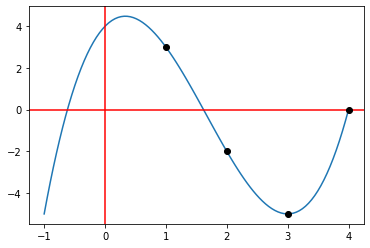

In [143]:
# Plotting the polynomial
def polynomial_coefficients(xs, coeffs):
    order = len(coeffs)
    print(f'# This is a polynomial of order {order - 1}.')
    ys = np.zeros(len(xs))  # Initialise an array of zeros of the required length.
    for i in range(order):
        ys += coeffs[i] * xs ** i
    return ys


xs = np.linspace(-1, 4, 100)  # Change this range according to your needs. Start, stop, number of steps.
coeffs = z.flatten().tolist()[::-1]

plt.plot(xs, polynomial_coefficients(xs, coeffs))
plt.axhline(y=0, color='r')  # Show xs axis
plt.axvline(x=0, color='r')  # Show y axis
points = [(1, 3), (2, -2), (3, -5), (4, 0)]
for p in points:
    plt.plot(p[0], p[1], 'o', color='black');
plt.plot(1, 3)
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Color Grading
The RGB color model is a method of describing colors. In this model each color is represented as a mixture of three basic colors: red, green, and blue. By varying intensities of these components a variety of colors can be obtained.


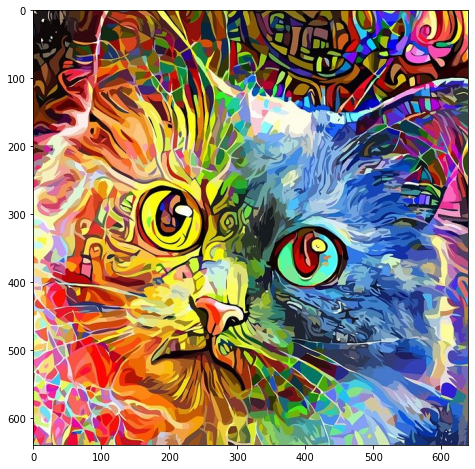

In [144]:
# import image
cat = plt.imread("cat.jpg")
plt.figure(figsize=(8,8))
plt.imshow(cat)
plt.show()

The `color_grader` function works as follows. It takes as its arguments a 3x3 matrix $A$ and an array representing an image. For each image pixel it takes the vector 

$$\mathbf{v} = \begin{bmatrix} r \\ g \\ b \\ \end{bmatrix}$$

with RGB coordinates of the pixel, and replaces it with the vector $A\mathbf{v}$, which specifies the new pixel color. Then it displays the image with colors given by the vectors $A\mathbf{v}$. Since valid RGB values are integers between 0 and 255, coordinates of each vector  𝐴𝐯  are rounded to the nearest integer in this range. In particular, if  𝐴𝐯  has negative coordinates they are rounded up to 0, and if it has coordinates exceeding 255 they are rounded down to 255.

Here is the implementation of the `color_grader` function:

In [145]:
def color_grader(A, img, width=8, height=8):
    A = np.array(A).astype(float)
    
    if img.dtype == 'uint8':
        img = img.astype(float)/255
    new_img = np.transpose(np.dot(A, np.transpose(img, axes = (0, 2, 1))), axes = (1, 2, 0))
    new_img[new_img < 0] = 0
    new_img[new_img > 1] = 1
    new_img = (255*new_img).astype('uint8')
    plt.figure(figsize=(width,height))
    plt.imshow(new_img)
    plt.show()

[[1.  0.  0.1]
 [1.  1.5 0.1]
 [0.1 0.3 1. ]]


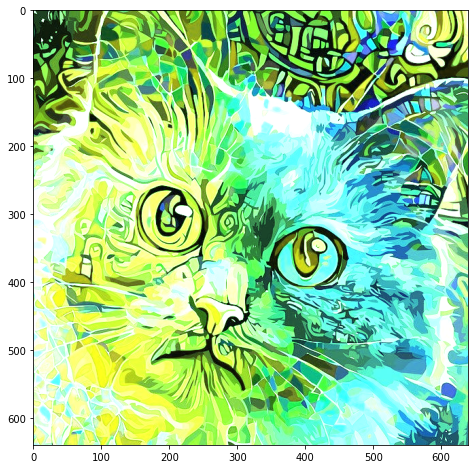

In [146]:
A = np.array([[1 , 0, 0.1], [1, 1.5, 0.1], [0.1, 0.3, 1]])
print(A)
color_grader(A, cat)

In each of the cases below find a $3\times 3$ matrix $A$ which transforms colors of image pixels as indicated. Use the function `color_grader` to display the resulting image of the balloon.

# Exercise 11

The matrix leaves the red component unchanged and sets the other components to 0:

$$A\begin{bmatrix} r \\ g \\ b \\ \end{bmatrix}  = \begin{bmatrix} r \\ 0 \\ 0 \\ \end{bmatrix} $$

Matrix A:
[[1 0 0]
 [0 0 0]
 [0 0 0]]


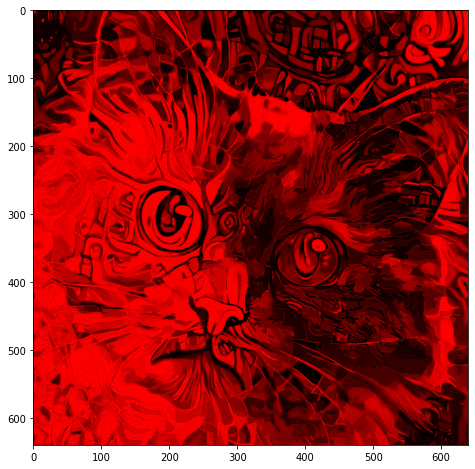

The chances of you being killed by this cat is low, but never zero...


In [147]:
A = np.array([[1, 0, 0], [0, 0, 0], [0, 0 ,0]])
print("Matrix A:")
print(A)
color_grader(A, cat)
print("The chances of you being killed by this cat is low, but never zero...")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 12

The matrix interchanges the red component with the blue component:

$$A\begin{bmatrix} r \\ g \\ b \\ \end{bmatrix}  = \begin{bmatrix} b \\ g \\ r \\ \end{bmatrix} $$

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


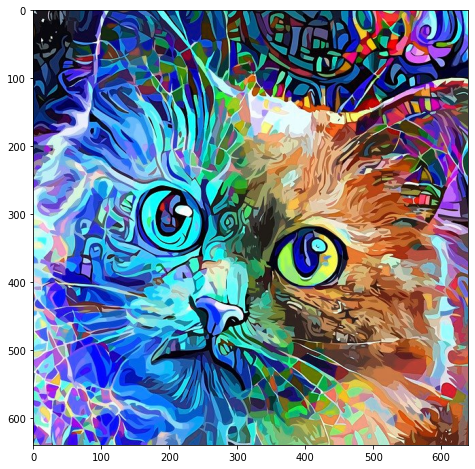

In [156]:
A = row_swap(np.eye(3), 0, 2)
print(A)
color_grader(A, cat)

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 13
The matrix divides all components by 2:

$$A\begin{bmatrix} r \\ g \\ b \\ \end{bmatrix}  = \begin{bmatrix} \frac{1}{2}r \\ \frac{1}{2}g \\ \frac{1}{2}b \\ \end{bmatrix} $$

[[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0.5]]


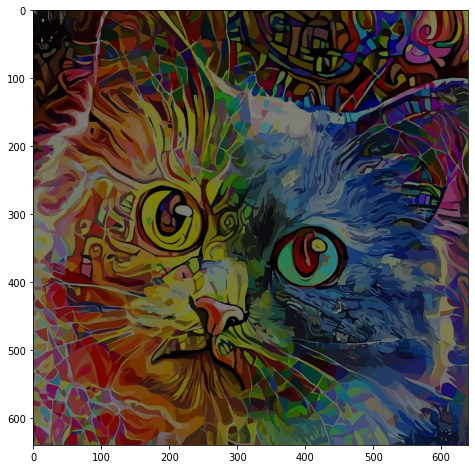

In [157]:
A = np.eye(3)/2
print(A)
color_grader(A, cat)

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Exercise 14
The matrix replaces all components by their average:

$$A\begin{bmatrix} r \\ g \\ b \\ \end{bmatrix}  = \begin{bmatrix} \dfrac{r+g+b}{3} \\[1mm] \dfrac{r+g+b}{3} \\[1mm] \dfrac{r+g+b}{3} \\ \end{bmatrix} $$

[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]


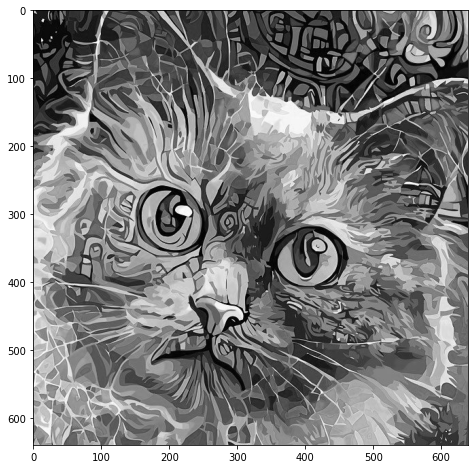

In [158]:
A = np.full((3, 3), 1/3)
print(A)
color_grader(A, cat)

<!-- END QUESTION -->

> This document was compiled, gathered and coded by the teaching assistant team and may be used only for educational purposes. The authors would like to thank the many projects and educational material that made their source code freely available on the internet, especially otter-grader that made the generation and sanitization of the notebook easier.